In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from rembg import remove

: 

In [ ]:
input_path = 'raton1.jpg'
output_path = 'raton1_sin_fondo.png'

input_img = cv.imread(input_path)
output = remove(input_img) # Hace magia con IA

cv.imwrite(output_path, output)

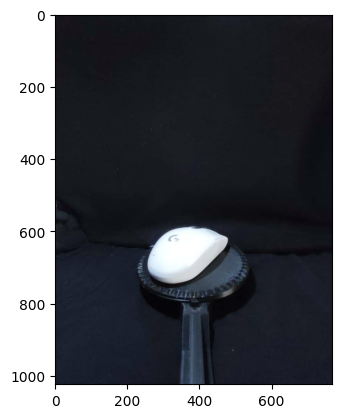

In [4]:
img_gray = []
img_color = []
for i in range(1,12):
  img_path = "raton"+str(i)+".jpeg"
  img = cv.imread(img_path)
  if img is None:
    print(f"No se pudo cargar la imagen {img_path}")
    continue
  img_color.append(img)
  img_gray.append(cv.cvtColor(img, cv.COLOR_BGR2GRAY))

if img_color:
  plt.imshow(img_color[0])
else:
  print("No se cargó ninguna imagen")

In [5]:
imgs_clean = []
for i in range(11):

  img_blur = cv.medianBlur(img_gray[i], 5)

  _, bin = cv.threshold(img_blur, 140, 255, cv.THRESH_BINARY)

  SE = cv.getStructuringElement(cv.MORPH_ELLIPSE, (35,35))
  bin_open = cv.dilate(bin, SE)

  clean = cv.bitwise_and(img_color[i],img_color[i], mask=bin_open)
  imgs_clean.append(clean)
  cv.imwrite('raton_clean'+str(i)+'.jpg', clean)

In [6]:
def feature_and_matching_knn_test(im1, im2):
  #Buscamos los puntos característicos con sus descriptores con el SIFT
  sift = cv.SIFT_create()
  kp1, des1 = sift.detectAndCompute(im1, None)
  kp2, des2 = sift.detectAndCompute(im2, None)
  #Buscamos una asicoación entre los puntos de las dos imágenes, usaremos el de fuerza bruta BFMatcher
  bf = cv.BFMatcher()

  matches = bf.knnMatch(des1, des2, k=2)
  #Escogemos sólo las asociaciones de puntos cercanos
  good_matches = []
  for m, n in matches:
    if m.distance <  n.distance*0.7:
      good_matches.append(m)

  #Medimos rendimiento
  img_matched = cv.drawMatchesKnn(im1, kp1, im2, kp2, good_matches, None, matchColor=(0, 255, 0),
                       singlePointColor=(0, 255, 0), flags=2)
  plt.imshow(img_matched)
  plt.axis('off')
  print(f"Puntos encontrados img1: {len(kp1)}")
  print(f"Puntos encontrados img2: {len(kp2)}")
  print(f"Buenos emparejamientos (Matches): {len(good_matches)}")


In [ ]:
def feature_and_matching(im1, im2):
  #Buscamos los puntos característicos con sus descriptores con el SIFT
  sift = cv.SIFT_create()
  kp1, des1 = sift.detectAndCompute(im1, None)
  kp2, des2 = sift.detectAndCompute(im2, None)
  #Buscamos una asicoación entre los puntos de las dos imágenes, usaremos el de fuerza bruta BFMatcher
  bf = cv.BFMatcher()

  matches = bf.match(des1, des2)
  #Escogemos sólo las asociaciones de puntos cercanos
  '''  
  matches = bf.knnmatch(des1, des2)
  good_matches = []
  pts1 = []
  pts2 = []
  for m, n in matches:
    if m.distance <  n.distance*0.7:
      good_matches.append(m)
      pts1.append(kp1[m.queryIdx].pt)
      pts2.append(kp2[m.trainIdx].pt)
  '''
  return (kp1, kp2[[p.trainIdx for p in matches]])


Caso 0,1
Puntos encontrados img1: 51
Puntos encontrados img2: 47
Buenos emparejamientos (Matches): 9
Caso 1,2
Puntos encontrados img1: 47
Puntos encontrados img2: 57
Buenos emparejamientos (Matches): 5
Caso 2,3
Puntos encontrados img1: 57
Puntos encontrados img2: 51
Buenos emparejamientos (Matches): 3
Caso 3,4
Puntos encontrados img1: 51
Puntos encontrados img2: 57
Buenos emparejamientos (Matches): 3
Caso 4,5
Puntos encontrados img1: 57
Puntos encontrados img2: 68
Buenos emparejamientos (Matches): 4
Caso 5,6
Puntos encontrados img1: 68
Puntos encontrados img2: 82
Buenos emparejamientos (Matches): 5
Caso 6,7
Puntos encontrados img1: 82
Puntos encontrados img2: 65
Buenos emparejamientos (Matches): 13
Caso 7,8
Puntos encontrados img1: 65
Puntos encontrados img2: 66
Buenos emparejamientos (Matches): 4
Caso 8,9
Puntos encontrados img1: 66
Puntos encontrados img2: 57
Buenos emparejamientos (Matches): 8
Caso 9,10
Puntos encontrados img1: 57
Puntos encontrados img2: 48
Buenos emparejamientos (

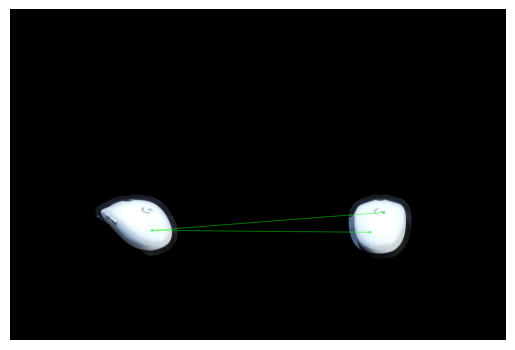

In [ ]:
for i,j in zip(range(10),range(1,11)):
  print(f'Caso {i},{j}')
  feature_and_matching_knn_test(imgs_clean[i], imgs_clean[j])


In [ ]:
def Sfm(pts1, pts2):
    K 

    E, mask = cv.findEssentialMat(pts1, pts2, K, method=cv.RANSAC, prob=0.999, threshold=1.0)